In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')

In [9]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df.shape

(10000, 12)

In [11]:
df.drop(columns=["customer_id"], inplace=True)

In [12]:
!python -m pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [13]:
df["country"] = encoder.fit_transform(df["country"])
df["gender"] = encoder.fit_transform(df["gender"])

In [14]:
df.sample(5)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9795,506,0,1,43,2,0.00,2,1,0,105568.60,0
3899,752,0,0,36,2,119912.46,1,1,0,124354.92,0
2726,829,1,0,37,3,103457.76,1,0,0,1114.12,0
5659,546,0,0,52,2,0.00,1,1,0,137332.37,1
2070,719,0,0,42,4,0.00,1,1,0,28465.86,1


In [15]:
df = pd.get_dummies(df, columns=["country"], drop_first=True)

In [16]:
df

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_1,country_2
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,1,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,True,False


In [17]:
X=df.drop(columns=["churn"]).values
y=df["churn"].values

In [18]:
y

array([1, 0, 1, ..., 1, 1, 0], shape=(10000,))

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
X

array([[-0.32622142, -1.09598752,  0.29351742, ...,  0.02188649,
        -0.57873591, -0.57380915],
       [-0.44003595, -1.09598752,  0.19816383, ...,  0.21653375,
        -0.57873591,  1.74273971],
       [-1.53679418, -1.09598752,  0.29351742, ...,  0.2406869 ,
        -0.57873591, -0.57380915],
       ...,
       [ 0.60498839, -1.09598752, -0.27860412, ..., -1.00864308,
        -0.57873591, -0.57380915],
       [ 1.25683526,  0.91241915,  0.29351742, ..., -0.12523071,
         1.72790383, -0.57380915],
       [ 1.46377078, -1.09598752, -1.04143285, ..., -1.07636976,
        -0.57873591, -0.57380915]], shape=(10000, 11))

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [28]:
!python -m pip install tensorflow
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [37]:
model = Sequential()

In [38]:
X.shape

(10000, 11)

In [39]:
model.add(Dense(11, activation="relu", input_dim=X_train.shape[1]))
model.add(Dense(11, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

c:\Users\NisargPatel\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [43]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,validation_split=0.2) 

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7634 - loss: 0.5252 - val_accuracy: 0.8075 - val_loss: 0.4487
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8125 - loss: 0.4398 - val_accuracy: 0.8319 - val_loss: 0.4201
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.8214 - loss: 0.4177 - val_accuracy: 0.8356 - val_loss: 0.4067
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8317 - loss: 0.4022 - val_accuracy: 0.8419 - val_loss: 0.3963
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8413 - loss: 0.3882 - val_accuracy: 0.8450 - val_loss: 0.3859
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8473 - loss: 0.3751 - val_accuracy: 0.8456 - val_loss: 0.3774
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8528 - loss: 0.3647 - val_accuracy: 0.8469 - val_loss: 0.3693
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8552 - loss: 0.3568 - val_ac

In [44]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step


In [47]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred.round())

0.864

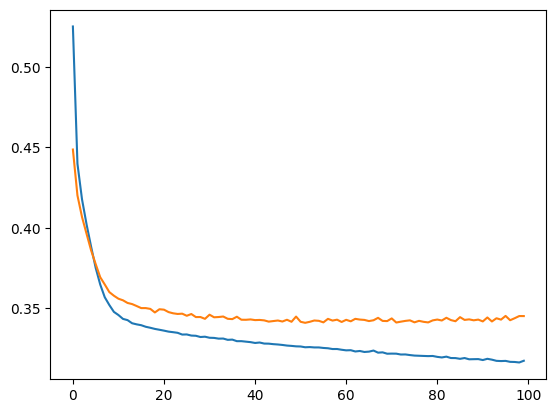

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')

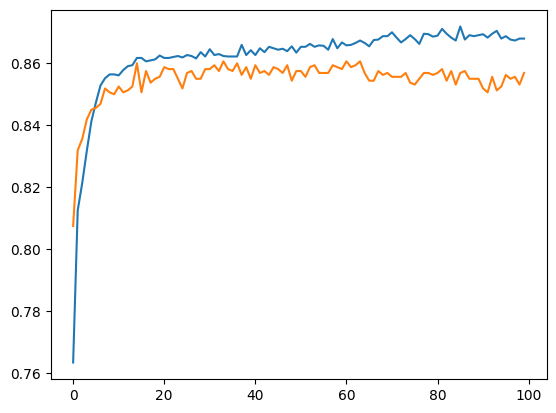

: 

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy') 